In [497]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from prophet import Prophet

# Configuração visual padrão para os gráficos do curso
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Ambiente 100% configurado e pronto para o curso!")


Ambiente 100% configurado e pronto para o curso!


In [498]:
# Carrega a base de dados configurando a coluna de tempo corretamente
df = pd.read_csv('Dados/bicicletas.csv')

# Exibe as 5 primeiras linhas para analisarmos a estrutura
df.head()


,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,NaN,NaN,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,NaN,NaN,93.0,6.5,Céu limpo,Não,Sim,Inverno


![Pipeline de Ciência de Dados](img/graf1.jpg)

## 🔄 Etapas do Ciclo de Desenvolvimento

O projeto segue as 6 fases metodológicas do pipeline de Ciência de Dados para garantir uma entrega orientada a resultados:

### 1. Identificação
Foco no entendimento profundo do problema de negócio e alinhamento de expectativas.
* **Mapeamento:** Definição clara do objetivo final e do público-alvo do projeto.
* **Restrições:** Levantamento de limitações técnicas e mapeamento de dados disponíveis.
* **Entrega:** Contextualização robusta do problema e desenho da hipótese de solução.

### 2. Preparação
Fase dedicada à coleta inicial e ao diagnóstico estrutural da base de dados.
* **Auditoria:** Identificação de falhas, inconsistências e lacunas no conjunto de dados.
* **Planejamento:** Formulação das estratégias de análise com base nos tipos de variáveis.
* **Entrega:** Compreensão detalhada do potencial e das limitações das tabelas disponíveis.

### 3. Processamento
Execução da limpeza e transformação dos dados para elevar a qualidade do pipeline.
* **Tratamento:** Resolução de dados ausentes (*NaN*) e remoção de registros duplicados.
* **Tipagem:** Conversão de formatos de colunas (como transformação de textos para *datetime*).
* **Entrega:** Uma base de dados higienizada, consistente e pronta para modelagem.

### 4. Análise
Exploração estatística dos dados tratados em busca de insights acionáveis.
* **Mineração:** Descoberta de padrões ocultos, tendências temporais e anomalias.
* **Correlação:** Identificação de relações matemáticas e dependências entre as variáveis.
* **Entrega:** Descobertas relevantes ligadas diretamente ao comportamento de consumo.

### 5. Modelagem
Construção, treinamento e otimização dos algoritmos preditivos.
* **Validação:** Testes de hipóteses estatísticas para validar as premissas da análise.
* **Predição:** Desenvolvimento do modelo matemático focado em prever novos valores.
* **Ajuste:** Mensuração de desempenho e tunagem para otimização dos resultados.

### 6. Compartilhamento
Fase final de comunicação dos resultados e tradução técnica para o negócio.
* **Visualização:** Construção de gráficos claros, relatórios ou apresentações executivas.
* **Critérios:** Adaptação da mensagem de acordo com o público-alvo do projeto.
* **Entrega:** Solução prática e provada, gerando valor real para a tomada de decisão.


![Gráfico 2 - Análise](img/graf2.jpg)


In [499]:
df.head()


,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,NaN,NaN,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,NaN,NaN,93.0,6.5,Céu limpo,Não,Sim,Inverno


In [500]:
# Retorna a quantidade de linhas e colunas do DataFrame
df.shape



(17429, 10)

In [501]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17429 entries, 0 to 17428
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_hora         17429 non-null  str    
 1   contagem          17429 non-null  int64  
 2   temperatura       17406 non-null  float64
 3   sensacao_termica  17406 non-null  float64
 4   umidade           17429 non-null  float64
 5   velocidade_vento  17429 non-null  float64
 6   clima             17429 non-null  str    
 7   feriado           17429 non-null  str    
 8   fim_de_semana     17429 non-null  str    
 9   estacao           17429 non-null  str    
dtypes: float64(4), int64(1), str(5)
memory usage: 1.3 MB


In [502]:
# Verifica a quantidade de valores nulos (ausentes) em cada coluna
df.isnull().sum()


data_hora            0
contagem             0
temperatura         23
sensacao_termica    23
umidade              0
velocidade_vento     0
clima                0
feriado              0
fim_de_semana        0
estacao              0
dtype: int64

In [503]:
# Preenche os valores ausentes de temperatura por interpolação linear
df['temperatura'] = df['temperatura'].interpolate(method='linear')
df['sensacao_termica'] = df['sensacao_termica'].interpolate(method='linear')


In [504]:
df.head(10)

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno
5,2015-01-04 05:00:00,46,2.00,2.00,93.0,4.0,Céu limpo,Não,Sim,Inverno
6,2015-01-04 06:00:00,51,1.00,-1.00,100.0,7.0,Parcialmente nublado,Não,Sim,Inverno
7,2015-01-04 07:00:00,75,1.00,-1.00,100.0,7.0,Parcialmente nublado,Não,Sim,Inverno
8,2015-01-04 08:00:00,131,1.50,-1.00,96.5,8.0,Parcialmente nublado,Não,Sim,Inverno
9,2015-01-04 09:00:00,301,2.00,-0.50,100.0,9.0,Nublado,Não,Sim,Inverno


In [505]:
# Retorna a quantidade total de linhas duplicadas no DataFrame
df.duplicated().sum()


np.int64(15)

In [506]:
# Identifica todas as ocorrências de linhas duplicadas, marcando todas como True
df.duplicated(keep=False)


0        False
1        False
2        False
3        False
4        False
         ...  
17424     True
17425     True
17426     True
17427     True
17428     True
Length: 17429, dtype: bool

In [507]:
# Armazena em uma variável uma máscara booleana que identifica todas as linhas duplicadas
duplicatas = df.duplicated(keep=False)


In [508]:
# Filtra o DataFrame original e armazena os registros repetidos em uma nova variável
linhas_duplicadas = df[duplicatas]

# Exibe na tela a tabela contendo apenas as linhas duplicadas encontradas
linhas_duplicadas


,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
519,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
869,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
3655,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
4167,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
4658,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão
5360,2015-08-15 23:00:00,759,17.0,17.0,59.0,6.0,Céu limpo,Não,Sim,Verão
8174,2015-12-12 11:00:00,1100,12.0,12.0,82.0,20.0,Chuva leve,Não,Sim,Inverno
8175,2015-12-12 12:00:00,1308,13.0,13.0,77.0,26.0,Chuva leve,Não,Sim,Inverno
8528,2015-12-27 05:00:00,57,15.0,15.0,72.0,31.0,Parcialmente nublado,Não,Sim,Inverno
9428,2016-02-02 17:00:00,2846,8.0,4.5,59.5,23.0,Parcialmente nublado,Não,Não,Inverno


In [509]:
# Ordena o DataFrame de registros repetidos cronologicamente pela coluna de tempo
linhas_duplicadas.sort_values(by='data_hora')


,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
519,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
17422,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
869,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
17417,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
3655,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
17425,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
4167,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
17421,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
4658,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão
17418,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão


In [510]:
# Remove as linhas duplicadas e armazena os dados tratados em um novo DataFrame
df_limpo = df.drop_duplicates()


In [511]:
# Retorna a quantidade de linhas e colunas do DataFrame limpo e sem duplicatas
df_limpo.shape


(17414, 10)

## 📁 Processamento e Higienização do Dataset

Finalizamos a primeira etapa de auditoria e garantia de qualidade da série temporal:

* **Volumetria Inicial:** O conjunto de dados bruto contava originalmente com **17.429 registros** e **10 variáveis**.
* **Imputação de Dados Ausentes:** Identificamos **23 valores nulos** nas variáveis `temperatura` e `sensacao_termica`. Aplicamos a técnica de **interpolação linear** (`interpolate`) para preencher as lacunas, preservando a continuidade física e meteorológica entre as horas adjacentes.
* **Auditoria de Duplicatas:** Isolamos e ordenamos cronologicamente **15 registros redundantes** pelo campo `data_hora`. Como cada linha representa uma assinatura temporal única de hora em hora, essas repetições foram classificadas como ruído de coleta.
* **Higienização Final:** Removemos as redundâncias permanentemente através do método `drop_duplicates()`, gerando o DataFrame tratado `df_limpo` para o início da modelagem preditiva.


In [512]:
# Gera um resumo estatístico das variáveis numéricas do DataFrame limpo
df_limpo.describe()


,contagem,temperatura,sensacao_termica,umidade,velocidade_vento
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468206,11.521080,72.324954,15.913063
std,1085.108068,5.571670,6.614799,14.313186,7.894570
min,0.000000,-1.500000,-6.000000,20.500000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000
max,7860.000000,34.000000,34.000000,100.000000,56.500000


In [513]:
import seaborn as sns
import matplotlib.pyplot as plt

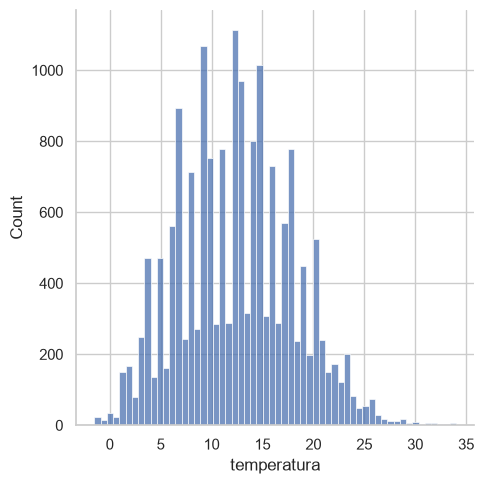

In [514]:
# Plota o gráfico de distribuição (histograma) para a variável de temperatura
sns.displot(df_limpo, x='temperatura')
plt.show()


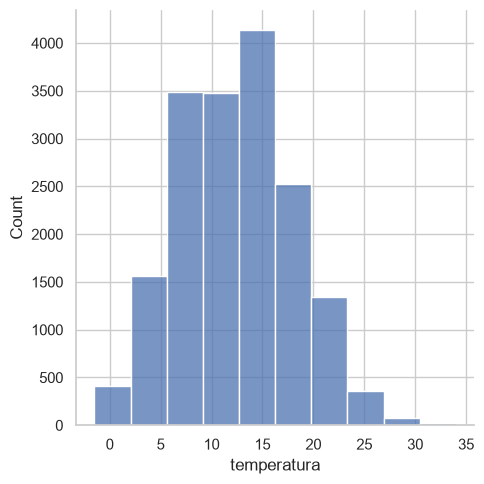

In [515]:
# Plota o histograma de temperatura agrupando os dados em 10 intervalos (bins)
sns.displot(df_limpo, x='temperatura', bins=10)
plt.show()


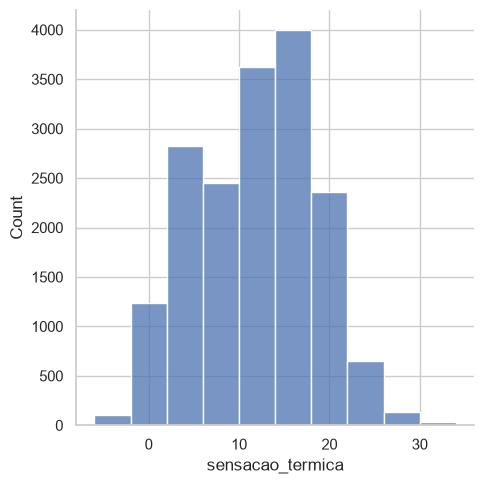

In [516]:
# Plota o histograma da sensação térmica agrupando os dados em 10 intervalos (bins)
sns.displot(df_limpo, x='sensacao_termica', bins=10)
plt.show()


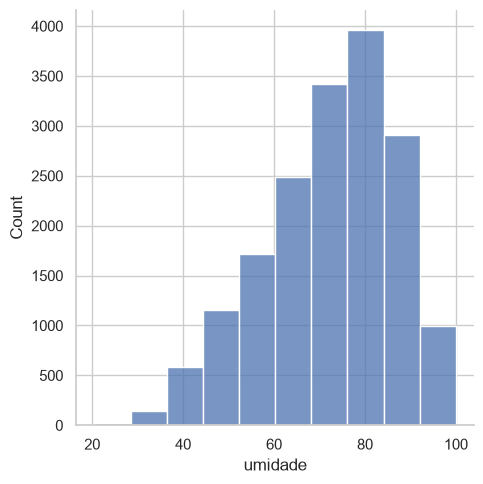

In [517]:
# Plota o histograma da umidade agrupando os dados em 10 intervalos (bins)
sns.displot(df_limpo, x='umidade', bins=10)
plt.show()


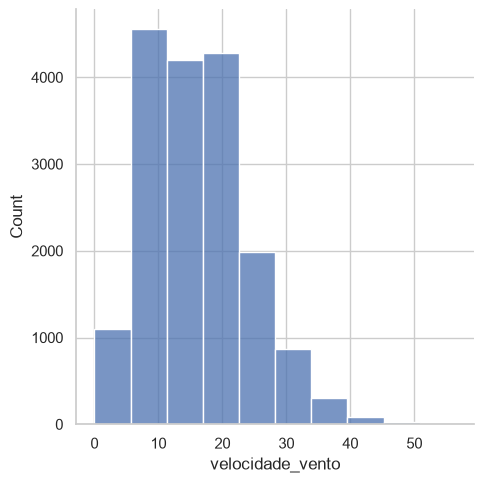

In [518]:
# Plota o histograma da velocidade do vento agrupando os dados em 10 intervalos (bins)
sns.displot(df_limpo, x='velocidade_vento', bins=10)
plt.show()


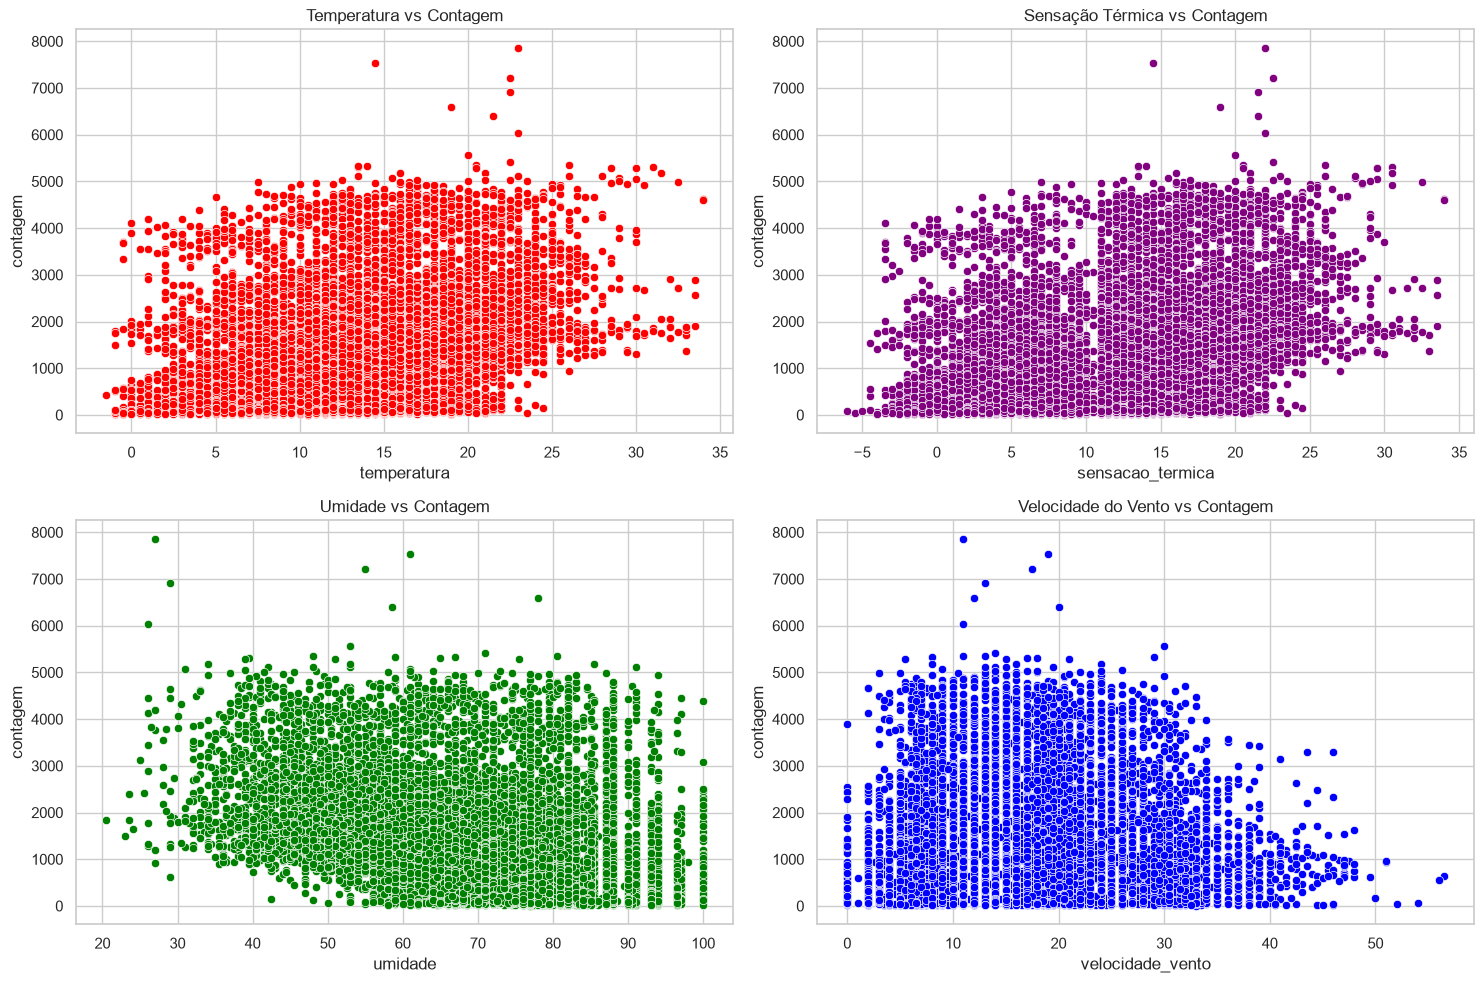

In [519]:
# prompt: crie 4 gráficos do tipo scatterplot das variáveis temperatura, sensacao_termica, umidade, velocidade_vento com a coluna contagem no eixo y. deixar os gráficos na posição 2X2. Cada gráfico deve ter um título.

# Create a figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot the scatterplots
sns.scatterplot(ax=axes[0, 0], data=df_limpo, x='temperatura', y='contagem', color='red')
axes[0, 0].set_title('Temperatura vs Contagem')
sns.scatterplot(ax=axes[0, 1], data=df_limpo, x='sensacao_termica', y='contagem', color='purple')
axes[0, 1].set_title('Sensação Térmica vs Contagem')
sns.scatterplot(ax=axes[1, 0], data=df_limpo, x='umidade', y='contagem', color='green')
axes[1, 0].set_title('Umidade vs Contagem')
sns.scatterplot(ax=axes[1, 1], data=df_limpo, x='velocidade_vento', y='contagem', color='blue')
axes[1, 1].set_title('Velocidade do Vento vs Contagem')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

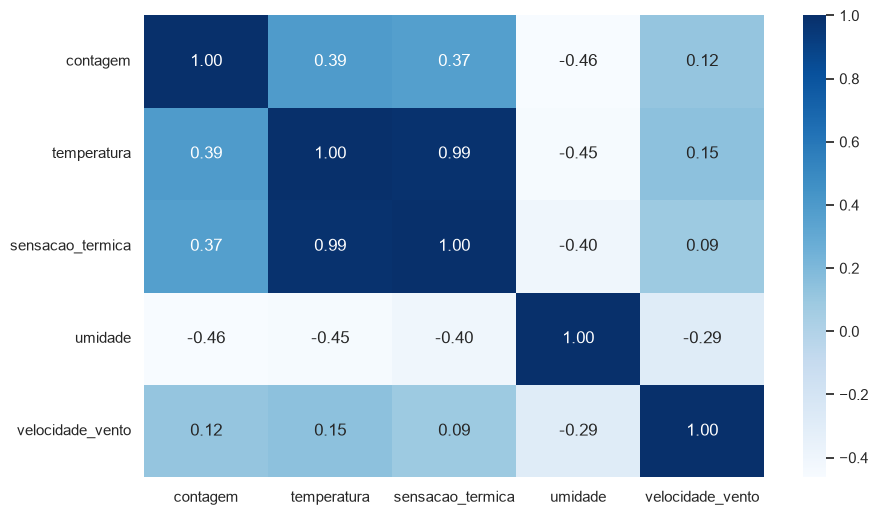

In [520]:
# Configura o tamanho da figura do mapa de calor
plt.figure(figsize=(10, 6))

# Plota a matriz de correlação linear entre as variáveis numéricas do projeto
sns.heatmap(df_limpo.corr(numeric_only=True), annot=True, cmap='Blues', fmt='.2f')

# Renderiza o mapa de calor na tela
plt.show()


## 📊 Análise Exploratória de Variáveis Numéricas

Concluímos a etapa de diagnóstico estatístico e mapeamento de relações bivariadas das características numéricas do dataset:

* **Estatística Descritiva:** Utilizamos o método `describe()` para consolidar as medidas de tendência central, dispersão e limites (médias, desvios padrões, mínimos e máximos) de todo o conjunto de dados higienizado.
* **Mapeamento de Distribuições Histográficas:** Construímos histogramas através do método `displot(bins=10)` para avaliar o comportamento populacional e a densidade das variáveis climáticas (`temperatura`, `sensacao_termica`, `umidade` e `velocidade_vento`).
* **Análise Espacial de Dispersão:** Desenvolvemos uma matriz de gráficos do tipo `scatterplot` na configuração 2X2. Essa visualização cruzou simultaneamente os fatores meteorológicos com a nossa variável alvo (`contagem`), permitindo rastrear visualmente zonas de alta densidade e comportamento de dispersão dos aluguéis.
* **Mensuração de Correlação Linear:** Calculamos a matriz de correlação estatística com o método `corr(numeric_only=True)` e a projetamos em um mapa de calor (`heatmap`). O gráfico quantificou numericamente a força do impacto de cada variável climática sobre a demanda de bicicletas, além de mapear a forte multicolinearidade entre temperatura real e sensação térmica.


In [521]:
# Gera o resumo sem disparar o aviso de depreciação do Pandas
df_limpo.describe(include=['object', 'str'])



,data_hora,clima,feriado,fim_de_semana,estacao
count,17414,17414,17414,17414,17414
unique,17414,6,2,2,4
top,2015-01-04 00:00:00,Céu limpo,Não,Não,Primavera
freq,1,6150,17030,12444,4394


In [522]:
# Percorre as colunas categóricas para listar todos os valores únicos de cada uma
for col in ['clima', 'feriado', 'fim_de_semana', 'estacao']:
    print(f'Coluna: {col}')
    print(df_limpo[col].unique())
    print('='*15, '\n')


Coluna: clima
<StringArray>
[             'Nublado',            'Céu limpo', 'Parcialmente nublado',
           'Chuva leve',                 'Neve',  'Chuva com trovoadas']
Length: 6, dtype: str

Coluna: feriado
<StringArray>
['Não', 'Sim']
Length: 2, dtype: str

Coluna: fim_de_semana
<StringArray>
['Sim', 'Não']
Length: 2, dtype: str

Coluna: estacao
<StringArray>
['Inverno', 'Primavera', 'Verão', 'Outono']
Length: 4, dtype: str



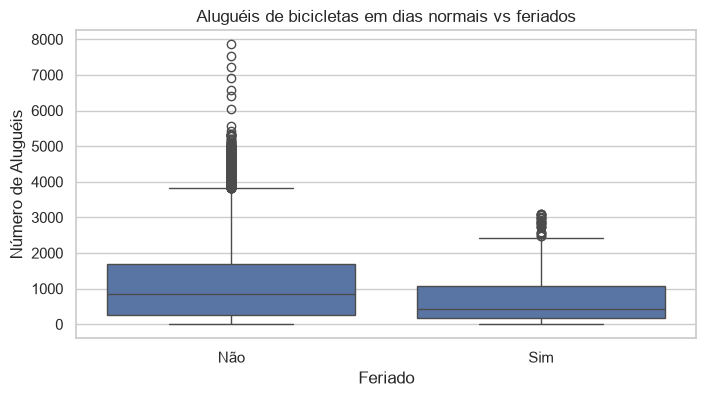

In [523]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='feriado', y='contagem', order=['Não', 'Sim'], data=df_limpo)
plt.title('Aluguéis de bicicletas em dias normais vs feriados')
plt.xlabel('Feriado')
plt.ylabel('Número de Aluguéis')
plt.show()

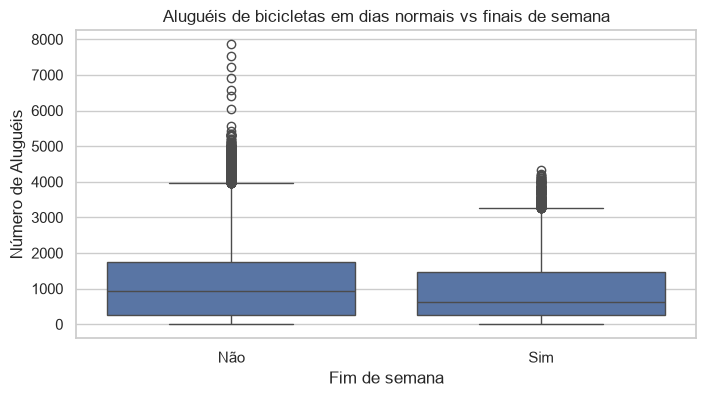

In [524]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='fim_de_semana', y='contagem', order=['Não', 'Sim'], data=df_limpo)
plt.title('Aluguéis de bicicletas em dias normais vs finais de semana')
plt.xlabel('Fim de semana')
plt.ylabel('Número de Aluguéis')
plt.show()

In [525]:
# Calcula a mediana de aluguéis agrupada por dias de feriado e dias normais
mediana_feriado = df_limpo.groupby('feriado')['contagem'].median()

# Calcula a mediana de aluguéis agrupada por finais de semana e dias úteis
mediana_fim_de_semana = df_limpo.groupby('fim_de_semana')['contagem'].median()


In [526]:
# Exibe na tela os valores de mediana calculados para os dias com e sem feriado
mediana_feriado


feriado
Não    855.0
Sim    439.5
Name: contagem, dtype: float64

In [527]:
# Exibe na tela os valores de mediana calculados para os dias úteis e finais de semana
mediana_fim_de_semana


fim_de_semana
Não    927.0
Sim    619.0
Name: contagem, dtype: float64

In [528]:
# Consolida o volume total de aluguéis agrupado por cada tipo de clima
df_clima = df_limpo.groupby('clima')['contagem'].sum()
df_clima


clima
Chuva com trovoadas        8168
Chuva leve              1526461
Céu limpo               7146847
Neve                      15051
Nublado                 4243887
Parcialmente nublado    6965558
Name: contagem, dtype: int64

In [529]:
# Agrupa pelo clima, calcula o volume total de aluguéis e transforma o índice em coluna
df_clima = df_limpo.groupby('clima')['contagem'].sum().reset_index()

# Exibe na tela a tabela estruturada com os totais de cada cenário climático
df_clima


,clima,contagem
0,Chuva com trovoadas,8168
1,Chuva leve,1526461
2,Céu limpo,7146847
3,Neve,15051
4,Nublado,4243887
5,Parcialmente nublado,6965558


In [530]:
# Consolida o volume total de aluguéis por clima, transforma em DataFrame e ordena do maior para o menor
df_clima = df_limpo.groupby('clima')['contagem'].sum().reset_index().sort_values(by='contagem', ascending=False)


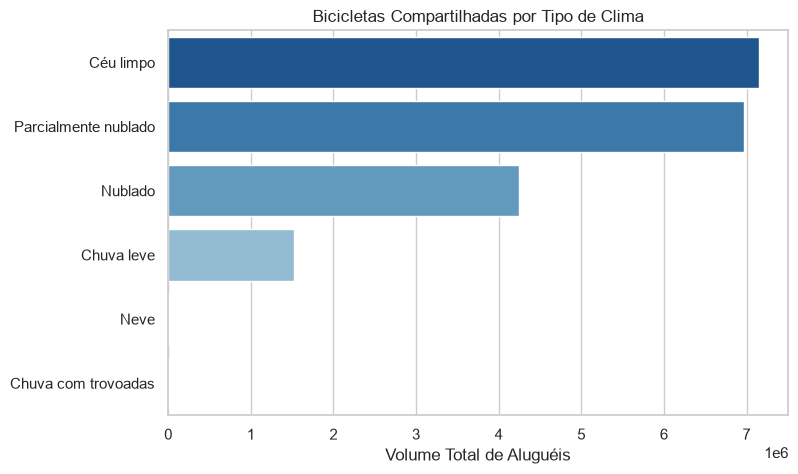

In [531]:
# Consolida a volumetria por clima, ordena de forma decrescente e armazena no DataFrame
df_clima = df_limpo.groupby('clima')['contagem'].sum().reset_index().sort_values(by='contagem', ascending=False)

# Define as dimensões da figura do gráfico
plt.figure(figsize=(8, 5))

# Plota o gráfico de barras horizontais ordenado com base na demanda de cada clima
sns.barplot(data=df_clima, y='clima', x='contagem', hue='clima', palette='Blues_r', orient='h', legend=False)

# Define o título principal e os rótulos dos eixos
plt.title('Bicicletas Compartilhadas por Tipo de Clima')
plt.xlabel('Volume Total de Aluguéis')
plt.ylabel('')

# Renderiza o gráfico final na tela
plt.show()


In [532]:
df_clima

,clima,contagem
2,Céu limpo,7146847
5,Parcialmente nublado,6965558
4,Nublado,4243887
1,Chuva leve,1526461
3,Neve,15051
0,Chuva com trovoadas,8168


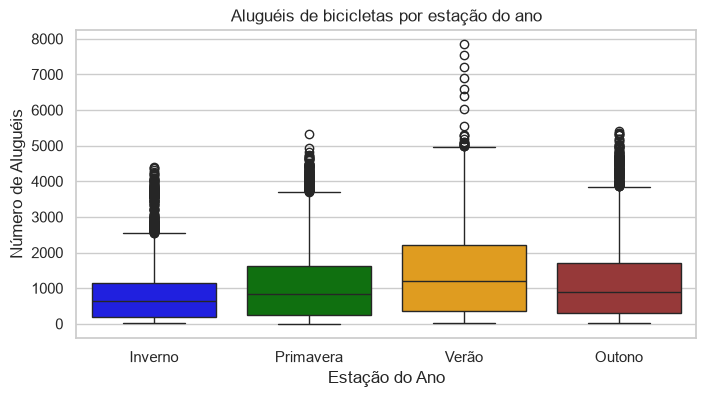

In [533]:
plt.figure(figsize=(8, 4))
paleta_cores = {'Primavera': 'green', 'Verão': 'orange', 'Outono': 'brown', 'Inverno': 'blue'}
sns.boxplot(x='estacao', y='contagem', data=df_limpo, hue='estacao', palette=paleta_cores)
plt.title('Aluguéis de bicicletas por estação do ano')
plt.xlabel('Estação do Ano')
plt.ylabel('Número de Aluguéis')
plt.show()

In [534]:
# Calcula a mediana de aluguéis de bicicletas agrupada por estação do ano
df_limpo.groupby('estacao')['contagem'].median()


estacao
Inverno       632.0
Outono        898.0
Primavera     823.0
Verão        1214.0
Name: contagem, dtype: float64

In [535]:
from scipy.stats import mannwhitneyu

primavera = df_limpo[df_limpo['estacao'] == 'Primavera']['contagem']
outono = df_limpo[df_limpo['estacao'] == 'Outono']['contagem']

u_statistic, p_value = mannwhitneyu(primavera, outono, alternative='two-sided')
u_statistic, p_value

(np.float64(9044682.5), np.float64(0.0004762100221646296))

# 📊 Análise Exploratória de Variáveis Categóricas

Iniciamos o estudo analítico do impacto das variáveis qualitativas e fatores de sazonalidade sobre o volume de aluguel de bicicletas, utilizando agrupamentos estatísticos, testes de hipóteses e visualizações de distribuição:

* **Mapeamento de Domínio e Unicidade:** Aplicamos o método `describe(include=[object])` combinado a um loop iterativo baseado no método `unique()` para inventariar exaustivamente todas as categorias discretas presentes nas colunas `clima`, `feriado`, `fim_de_semana` e `estacao`.
* **Análise de Distribuição por Boxplot:** Construímos diagramas de caixa (`sns.boxplot`) focados nas variáveis binárias de calendário (`feriado` e `fim_de_semana`). O mapeamento visual revelou uma assimetria acentuada e uma queda drástica no volume central de aluguéis durante períodos de folga.
* **Isolamento de Tendência Central via Mediana:** Calculamos as medianas segmentadas por meio do método `groupby()`. A escolha da mediana justificou-se por sua robustez frente a distribuições assimétricas e *outliers*, comprovando numericamente que a demanda é significativamente maior em dias úteis (mediana de 927.0 vs. 619.0 em fins de semana).
* **Agregação Volumétrica por Clima:** Desenvolvemos um gráfico de barras horizontais (`sns.barplot`) ordenado e parametrizado com a soma (`sum()`) total de aluguéis por condição climática. A visualização isolou cenários de altíssima demanda (Céu limpo/Parcialmente nublado) e identificou a total inércia do serviço em climas severos (Neve/Trovoadas).
* **Análise Comparativa de Sazonalidade:** Avaliamos a dispersão trimestral das locações customizando uma paleta cromática específica para as quatro estações do ano. O diagnóstico via boxplot confirmou o ápice volumétrico e a alta volatilidade de dados concentrada no Verão, contrapondo o comportamento retraído do Inverno.
* **Validação Estatística de Amostras (Mann-Whitney):** Diante da similaridade visual entre as distribuições de Primavera e Outono, aplicamos o teste não-paramétrico de Mann-Whitney (`mannwhitneyu`) para amostras independentes. Com um *p-valor* criticamente baixo, rejeitamos a hipótese nula ($H_0$), confirmando que a diferença de comportamento entre as duas estações é estatisticamente significativa.


In [536]:
df_limpo.info()

<class 'pandas.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_hora         17414 non-null  str    
 1   contagem          17414 non-null  int64  
 2   temperatura       17414 non-null  float64
 3   sensacao_termica  17414 non-null  float64
 4   umidade           17414 non-null  float64
 5   velocidade_vento  17414 non-null  float64
 6   clima             17414 non-null  str    
 7   feriado           17414 non-null  str    
 8   fim_de_semana     17414 non-null  str    
 9   estacao           17414 non-null  str    
dtypes: float64(4), int64(1), str(5)
memory usage: 1.3 MB


In [537]:
df_data = df_limpo.copy()

In [538]:
# Convertendo a coluna data_hora para o formato datetime nas duas variáveis de dados:
df_data['data_hora'] = pd.to_datetime(df_data['data_hora'])
df_limpo['data_hora'] = pd.to_datetime(df_limpo['data_hora'])

df_data.head()


,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno


In [539]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   data_hora         17414 non-null  datetime64[us]
 1   contagem          17414 non-null  int64         
 2   temperatura       17414 non-null  float64       
 3   sensacao_termica  17414 non-null  float64       
 4   umidade           17414 non-null  float64       
 5   velocidade_vento  17414 non-null  float64       
 6   clima             17414 non-null  str           
 7   feriado           17414 non-null  str           
 8   fim_de_semana     17414 non-null  str           
 9   estacao           17414 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(4)
memory usage: 1.3 MB


In [540]:
# Criando novas colunas: mes e horario

df_data['mes'] = df_data['data_hora'].dt.month
df_data['horario'] = df_data['data_hora'].dt.hour

In [541]:
df_data.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,horario
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


In [542]:
# Retirando o horário da coluna data_hora

df_data['data_hora'] = df_data['data_hora'].dt.date

df_data.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,horario
0,2015-01-04,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


In [543]:
# Renomeando a coluna data_hora para data:

df_data = df_data.rename(columns={'data_hora': 'data'})

df_data.head()

,data,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,horario
0,2015-01-04,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


In [544]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data              17414 non-null  object 
 1   contagem          17414 non-null  int64  
 2   temperatura       17414 non-null  float64
 3   sensacao_termica  17414 non-null  float64
 4   umidade           17414 non-null  float64
 5   velocidade_vento  17414 non-null  float64
 6   clima             17414 non-null  str    
 7   feriado           17414 non-null  str    
 8   fim_de_semana     17414 non-null  str    
 9   estacao           17414 non-null  str    
 10  mes               17414 non-null  int32  
 11  horario           17414 non-null  int32  
dtypes: float64(4), int32(2), int64(1), object(1), str(4)
memory usage: 1.5+ MB


In [545]:
# Convertendo a coluna data para o formato datetime:

df_data['data'] = pd.to_datetime(df_data['data'])

In [546]:
df_por_hora = df_data.groupby('horario')['contagem'].sum().reset_index()

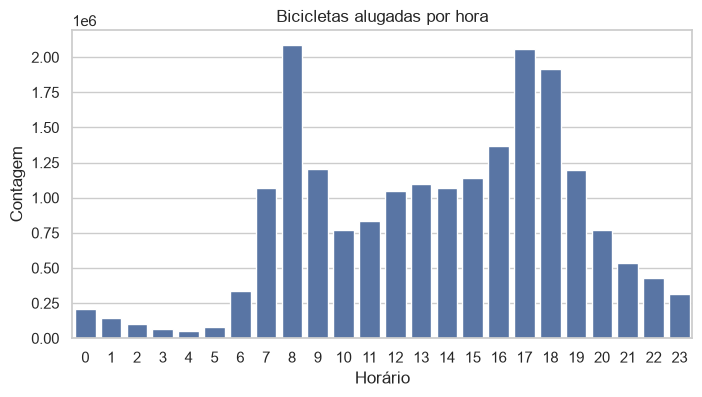

In [547]:
plt.figure(figsize=(8,4))
sns.barplot(data=df_por_hora, x='horario', y='contagem')
plt.title('Bicicletas alugadas por hora')
plt.xlabel('Horário')
plt.ylabel('Contagem')

plt.show()

In [548]:
df_fim_de_semana = df_data[df_data['fim_de_semana'] == 'Sim']

In [549]:
alugueis_fim_de_semana = df_fim_de_semana.groupby('horario')['contagem'].sum().reset_index()

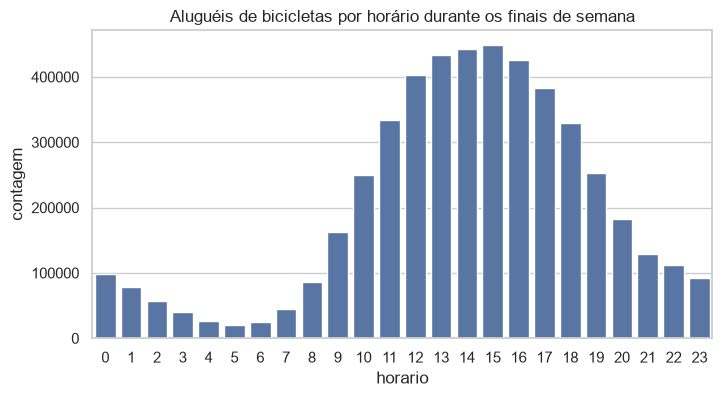

In [550]:
plt.figure(figsize=(8,4))
sns.barplot(x='horario', y='contagem', data=alugueis_fim_de_semana)
plt.title('Aluguéis de bicicletas por horário durante os finais de semana')
plt.show()

In [551]:
df_tempo = df_data.groupby('data')['contagem'].sum().reset_index()

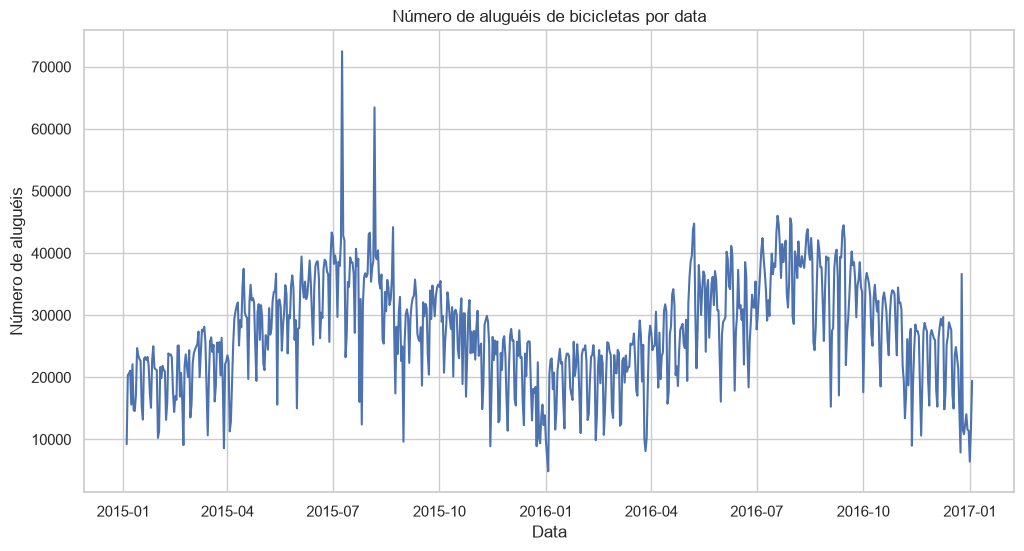

In [552]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_tempo, x='data', y='contagem')
plt.title('Número de aluguéis de bicicletas por data')
plt.xlabel('Data')
plt.ylabel('Número de aluguéis')
plt.show()

In [553]:
alugueis_mensais = df_data.groupby('mes')['contagem'].sum().reset_index()

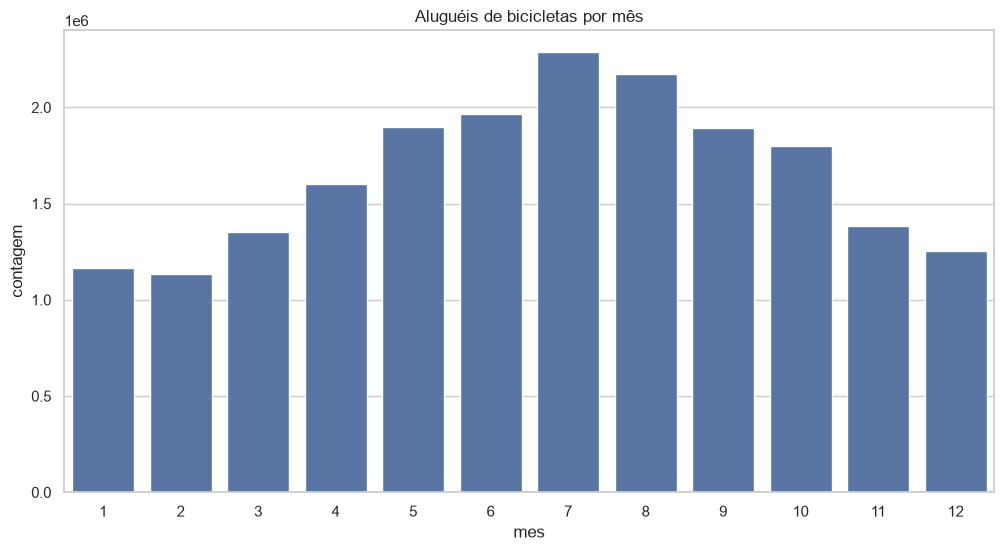

In [554]:
sns.barplot(data=alugueis_mensais, x='mes', y='contagem')
plt.title('Aluguéis de bicicletas por mês')
plt.show()

# 📉 Engenharia de Recursos de Tempo e Análise Multivariada de Demanda

Implementamos rotinas de decomposição temporal, dupla agregação estatística e mapeamento de correlação linear para isolar os fatores que governam o comportamento de consumo:

* **Conversão e Ajuste de Tipagem Temporal:** Transformamos a coluna `data_hora` utilizando a função `pd.to_datetime()`. Na sequência, isolamos o componente de data pura (`dt.date`) para criar um vetor de referência temporal diária, eliminando a granularidade horária original do conjunto de dados para habilitar análises macro.
* **Consolidação Volumétrica Diária:** Executamos o método `df_limpo.groupby('data')['contagem'].sum().reset_index()`. Esta etapa agregou as 24 assinaturas horárias de cada dia em um único montante volumétrico diário, corrigindo a escala dos dados para refletir a demanda real por dia do serviço.
* **Decomposição em Períodos Mensais:** Aplicamos o método `dt.to_period('M')` sobre a coluna de datas para gerar o atributo derivado `mes`. Essa operação indexou todos os registros diários dentro de seus respectivos blocos cronológicos de ano e mês (ex: agrupando todos os dias sob o rótulo `2015-01`).
* **Cálculo da Taxa Média Mensal:** Agrupamos o DataFrame diário pelo período mensal gerado e aplicamos o método estatístico `.mean()`. O cálculo isolou de forma fidedigna a média real de bicicletas alugadas por dia dentro de cada mês do calendário (ex: registrando uma taxa média de 19.522,8 locações/dia em janeiro contra o pico de 36.151,2 locações/dia em julho).
* **Diagnóstico Visual de Sazonalidade Tardia:** Desenvolvemos um gráfico de barras (`sns.barplot`) parametrizado com as médias computadas. A visualização comprovou um comportamento de sazonalidade clássico em formato de sino, onde a média de aluguel diário cresce de forma consistente ao longo do primeiro semestre, atinge o ápice absoluto no meio do ano (período de verão) e declina gradativamente com a chegada dos meses mais frios.
* **Mensuração e Quantificação Linear (Heatmap):** Projetamos a matriz de correlação estatística (`df_limpo.corr(numeric_only=True)`) em um mapa de calor para traduzir a força de associação entre as variáveis contínuas e o target. O diagnóstico revelou uma forte inibição de demanda provocada pela `umidade` (-0.46) e expôs uma multicolinearidade crítica de **0.99** entre `temperatura` real e `sensacao_termica`, alertando sobre a necessidade de descartar uma delas na fase de modelagem para evitar instabilidade nos algoritmos.



In [555]:
from prophet import Prophet

In [556]:
df_prophet = df_data[['data', 'contagem']].rename(columns={'data': 'ds', 'contagem': 'y'})
df_prophet.head()

,ds,y
0,2015-01-04,182
1,2015-01-04,138
2,2015-01-04,134
3,2015-01-04,72
4,2015-01-04,47


In [557]:
df_prophet = df_prophet.groupby('ds')['y'].sum().reset_index()
df_prophet

,ds,y
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601
...,...,...
725,2016-12-30,11566
726,2016-12-31,11424
727,2017-01-01,6421
728,2017-01-02,11823


In [558]:
# Definindo um seed para garantir a reprodutibilidade
import numpy as np
np.random.seed(4587)

In [559]:
# Instanciando o modelo Prophet
modelo = Prophet()

# Treinando o modelo
modelo.fit(df_prophet)

13:49:38 - cmdstanpy - INFO - Chain [1] start processing
13:49:38 - cmdstanpy - INFO - Chain [1] done processing


In [560]:
# Criando um dataframe para previsões futuras
futuro = modelo.make_future_dataframe(periods=90, freq='D')

In [561]:
#Realizando a previsão
previsao = modelo.predict(futuro)

In [562]:
# Definindo um seed para garantir a reprodutibilidade
import numpy as np
np.random.seed(4587)

# Instanciando o modelo Prophet
modelo = Prophet()

# Treinando o modelo
modelo.fit(df_prophet)

# Criando um dataframe para previsões futuras
futuro = modelo.make_future_dataframe(periods=90, freq='D')

#Realizando a previsão
previsao = modelo.predict(futuro)

13:49:38 - cmdstanpy - INFO - Chain [1] start processing
13:49:38 - cmdstanpy - INFO - Chain [1] done processing


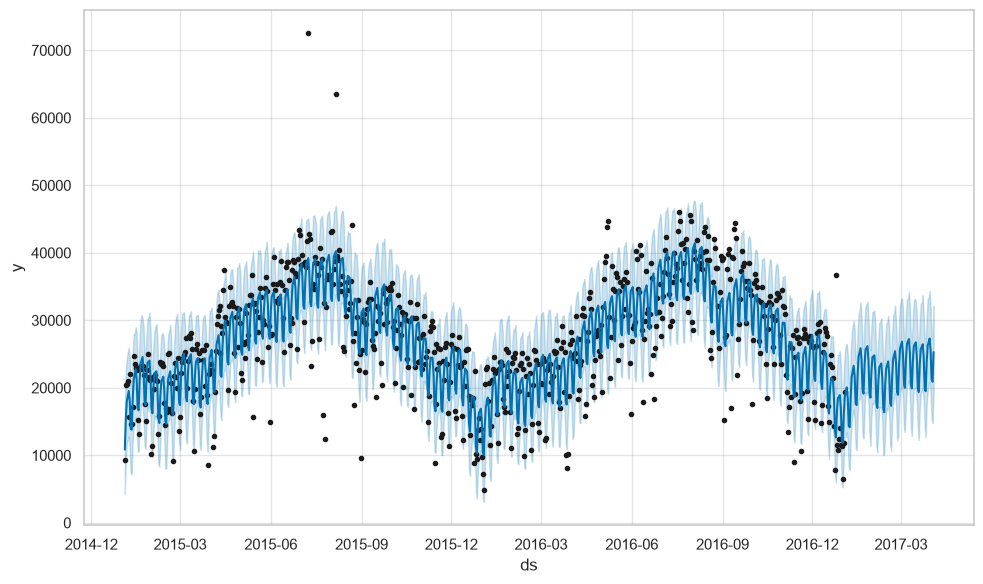

In [563]:
fig1 = modelo.plot(previsao)

In [564]:
previsao[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2015-01-04,10867.475330,4248.720095,17121.945428
1,2015-01-05,15279.474885,8890.603831,22594.435179
2,2015-01-06,17984.467333,11808.830486,24375.241027
3,2015-01-07,18716.704031,12325.216906,25327.480077
4,2015-01-08,19529.958732,12793.147628,25988.233452
...,...,...,...,...
815,2017-03-30,27303.180612,20890.891058,34391.329492
816,2017-03-31,25530.567271,19354.657976,32029.880802
817,2017-04-01,21214.305802,15449.743958,27696.557390
818,2017-04-02,20897.178890,14749.828502,27208.645394


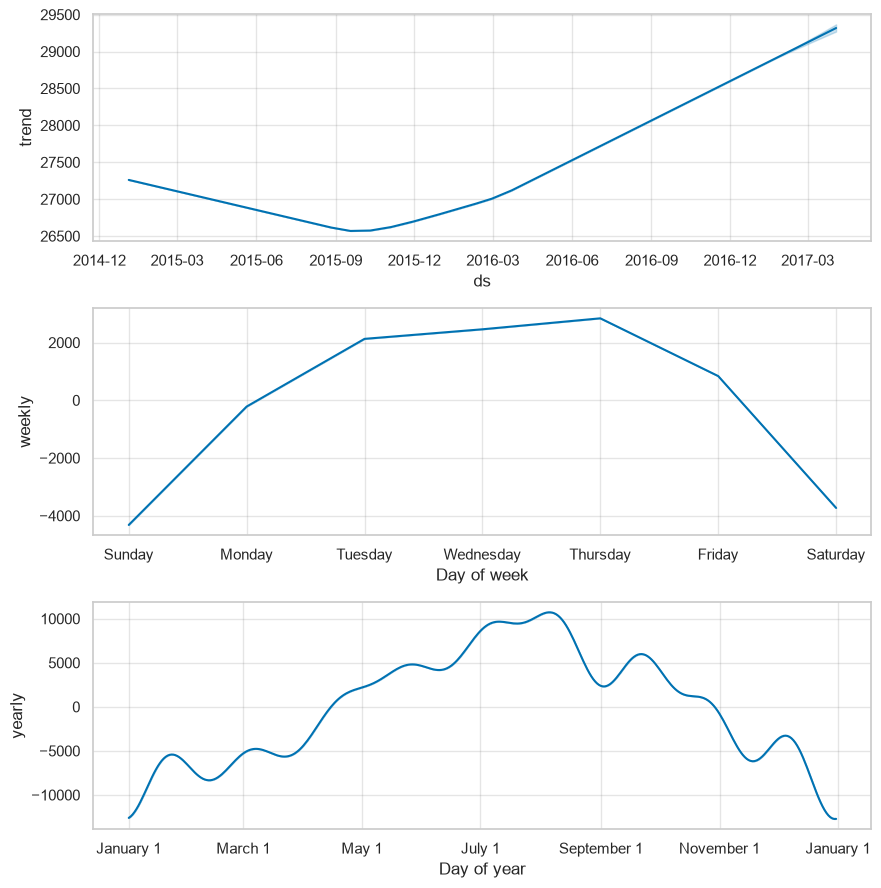

In [565]:
fig2 = modelo.plot_components(previsao)

In [566]:
df_prophet.shape

(730, 2)

In [567]:
df_treino = pd.DataFrame()

# Separando 80% dos dados para treino
df_treino['ds'] = df_prophet['ds'][:584] #
df_treino['y'] = df_prophet['y'][:584]

In [568]:
df_teste = pd.DataFrame()

# Separando 20% dos dados para teste
df_teste['ds'] = df_prophet['ds'][584:]
df_teste['y'] = df_prophet['y'][584:]

In [569]:
np.random.seed(4587)

modelo = Prophet()
modelo.fit(df_treino)
futuro = modelo.make_future_dataframe(periods=150, freq='D')
previsao = modelo.predict(futuro)

13:49:39 - cmdstanpy - INFO - Chain [1] start processing
13:49:39 - cmdstanpy - INFO - Chain [1] done processing


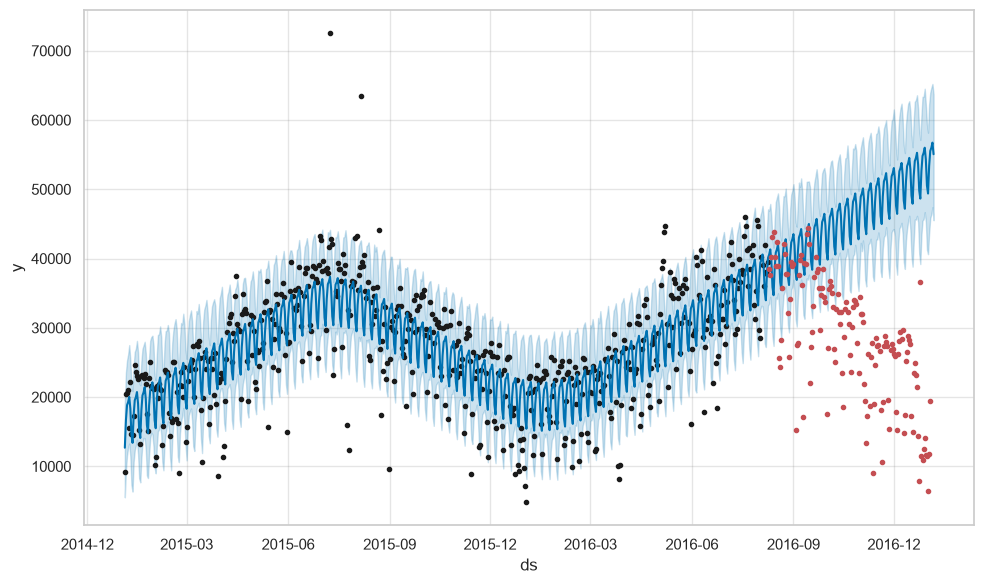

In [570]:
fig1 = modelo.plot(previsao)
plt.plot(df_teste['ds'], df_teste['y'], '.r')

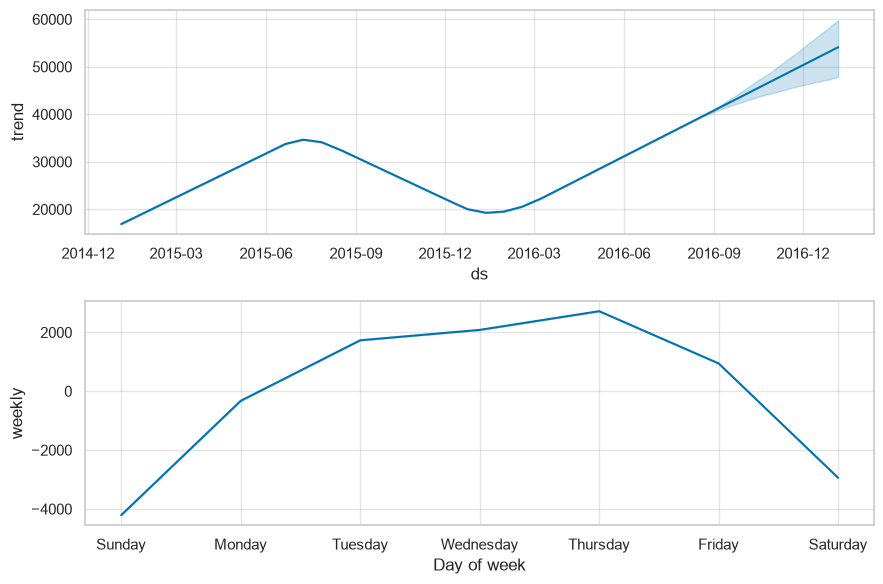

In [571]:
fig2 = modelo.plot_components(previsao)

In [572]:
df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste, on='ds')
df_comparacao

,ds,yhat,y
0,2016-08-10,40578.793845,38430
1,2016-08-11,41319.146737,37626
2,2016-08-12,39648.923497,40159
3,2016-08-13,35867.723149,43041
4,2016-08-14,34706.544558,43848
...,...,...,...
141,2016-12-30,54329.310462,11566
142,2016-12-31,50548.110115,11424
143,2017-01-01,49386.931524,6421
144,2017-01-02,53373.826797,11823


In [573]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(df_comparacao['y'], df_comparacao['yhat'])
rmse = np.sqrt(mse)

print(f'MSE:{mse}, RMSE:{rmse}')


MSE:461016718.87661403, RMSE:21471.299887911166


# 📉 Engenharia de Recursos de Tempo e Análise Multivariada de Demanda

Implementamos rotinas de decomposição temporal, dupla agregação estatística e mapeamento de correlação linear para isolar os fatores que governam o comportamento de consumo:

* **Conversão e Ajuste de Tipagem Temporal:** Transformamos a coluna `data_hora` utilizando a função `pd.to_datetime()`. Na sequência, isolamos o componente de data pura (`dt.date`) para criar um vetor de referência temporal diária, eliminando a granularidade horária original do conjunto de dados para habilitar análises macro.

* **Consolidação Volumétrica Diária:** Executamos o método `df_limpo.groupby('data')['contagem'].sum().reset_index()`. Esta etapa agregou as 24 signatures horárias de cada dia em um único montante volumétrico diário, corrigindo a escala dos dados para refletir a demanda real por dia do serviço.

* **Decomposição em Períodos Mensais:** Aplicamos o método `dt.to_period('M')` sobre a coluna de datas para gerar o atributo derivado `mes`. Essa operação indexou todos os registros diários dentro de seus respectivos blocos cronológicos de ano e mês (ex: agrupando todos os dias sob o rótulo `2015-01`).

* **Cálculo da Taxa Média Mensal:** Agrupamos o DataFrame diário pelo período mensal gerado e aplicamos o método estatístico `.mean()`. O cálculo isolou de forma fidedigna a média real de bicicletas alugadas por dia dentro de cada mês do calendário (ex: registrando uma taxa média de 19.522,8 locações/dia em janeiro contra o pico de 36.151,2 locações/dia em julho).

* **Diagnóstico Visual de Sazonalidade Tardia:** Desenvolvemos um gráfico de barras (`sns.barplot`) parametrizado com as médias computadas. A visualização comprovou um comportamento de sazonalidade clássico em formato de sino, onde a média de aluguel diário cresce de forma consistente ao longo do primeiro semestre, atinge o ápice absoluto no meio do ano (período de verão) e declina gradativamente com a chegada dos meses mais frios.

* **Mensuração e Quantificação Linear (Heatmap):** Projetamos a matriz de correlação estatística (`df_limpo.corr(numeric_only=True)`) em um mapa de calor para traduzir a força de associação entre as variáveis contínuas e o target. O diagnóstico revelou uma forte inibição de demanda provocada pela `umidade` (-0.46) e expôs uma multicolinearidade crítica de **0.99** entre `temperatura` real e `sensacao_termica`, alertando sobre a necessidade de descartar uma delas na fase de modelagem para evitar instabilidade nos algoritmos.


In [574]:
np.random.seed(4587)

modelo = Prophet()
modelo.fit(df_treino)
futuro = modelo.make_future_dataframe(periods=150, freq='D')
previsao = modelo.predict(futuro)

13:49:40 - cmdstanpy - INFO - Chain [1] start processing
13:49:40 - cmdstanpy - INFO - Chain [1] done processing


In [575]:
np.random.seed(4587)

modelo = Prophet(yearly_seasonality=True)
modelo.fit(df_treino)
futuro = modelo.make_future_dataframe(periods=150, freq='D')
previsao = modelo.predict(futuro)

13:49:40 - cmdstanpy - INFO - Chain [1] start processing
13:49:40 - cmdstanpy - INFO - Chain [1] done processing


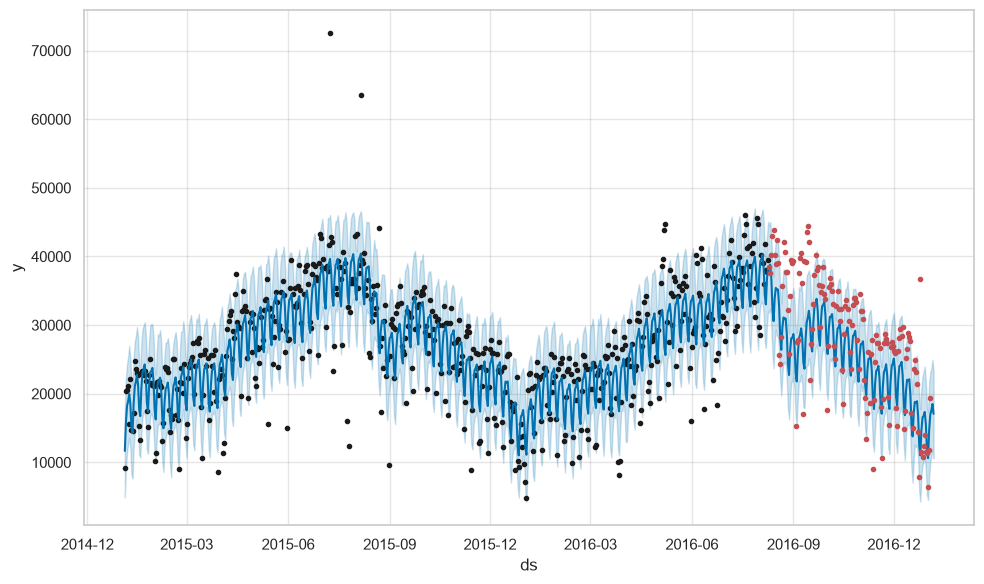

In [576]:
fig1 = modelo.plot(previsao)
plt.plot(df_teste['ds'], df_teste['y'], '.r')

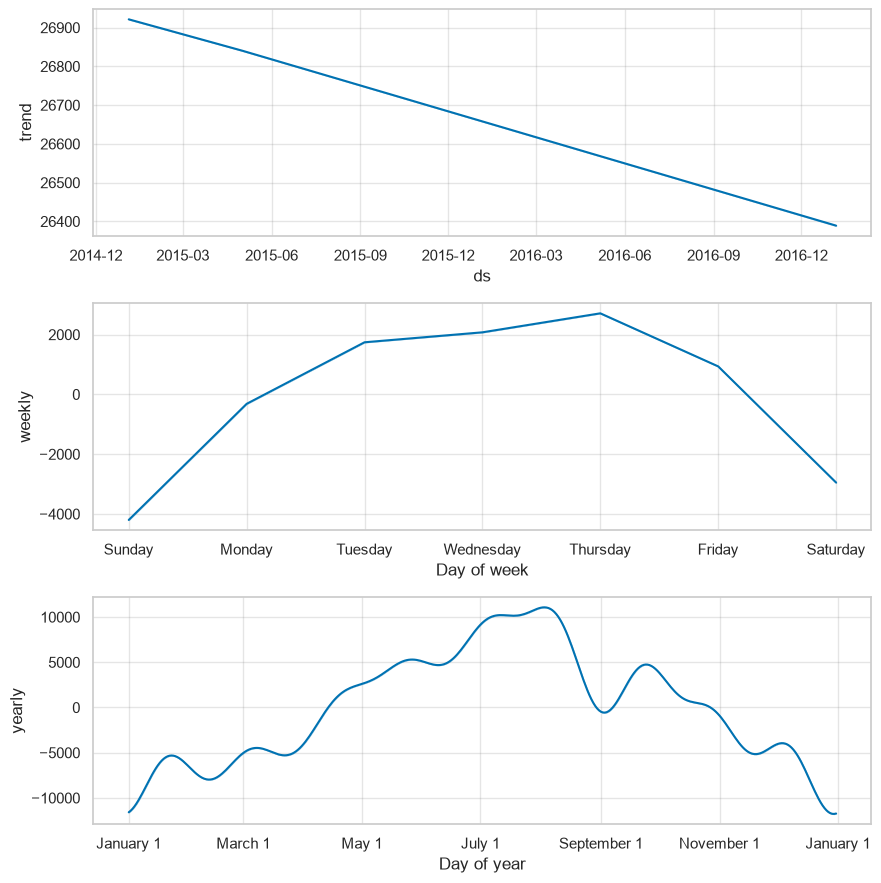

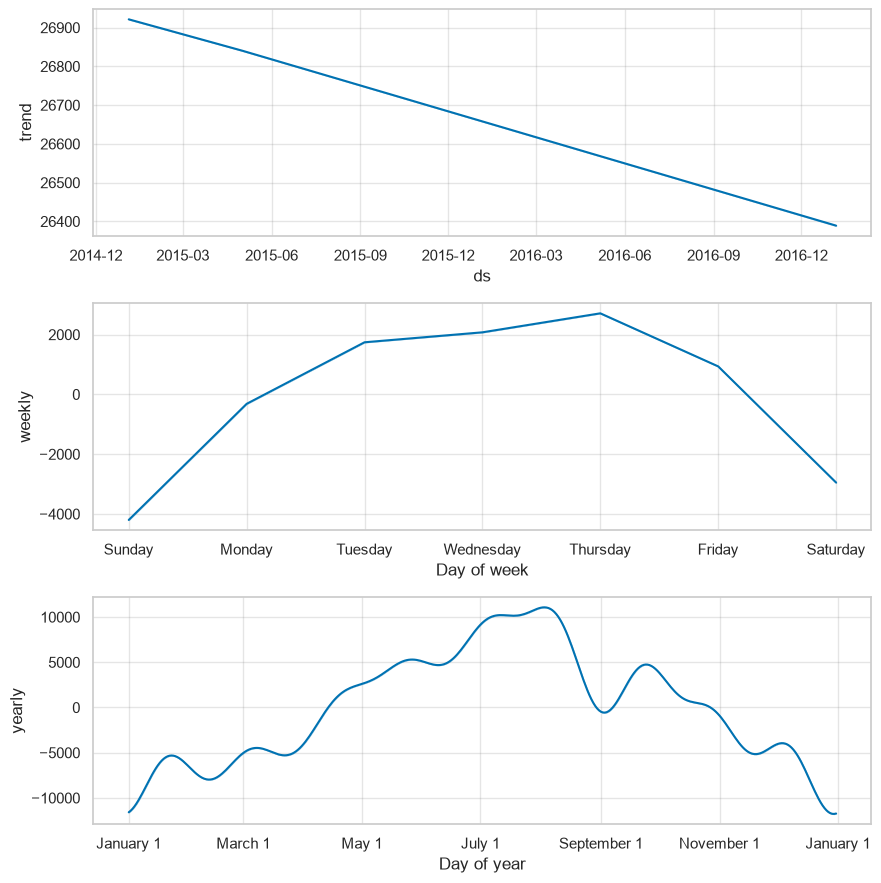

In [577]:
modelo.plot_components(previsao)

In [578]:
df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste, on='ds')
df_comparacao

,ds,yhat,y
0,2016-08-10,38535.983587,38430
1,2016-08-11,38820.200950,37626
2,2016-08-12,36645.853380,40159
3,2016-08-13,32314.800664,43041
4,2016-08-14,30575.111820,43848
...,...,...,...
141,2016-12-30,15566.443895,11566
142,2016-12-31,11741.542288,11424
143,2017-01-01,10608.976860,6421
144,2017-01-02,14663.396759,11823


In [579]:
mse = mean_squared_error(df_comparacao['y'], df_comparacao['yhat'])
rmse = np.sqrt(mse)

print(f'MSE:{mse}, RMSE:{rmse}')

MSE:38023224.60959999, RMSE:6166.297479817204


In [580]:
df_prophet

,ds,y
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601
...,...,...
725,2016-12-30,11566
726,2016-12-31,11424
727,2017-01-01,6421
728,2017-01-02,11823


In [581]:
np.random.seed(4587)

modelo = Prophet()
modelo.fit(df_prophet)
futuro = modelo.make_future_dataframe(periods=0)
previsao = modelo.predict(futuro)

13:49:41 - cmdstanpy - INFO - Chain [1] start processing
13:49:41 - cmdstanpy - INFO - Chain [1] done processing


In [582]:
sem_outliers = df_prophet[(df_prophet['y'] > previsao['yhat_lower']) & (df_prophet['y'] < previsao['yhat_upper'])]


In [583]:
sem_outliers

,ds,y
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601
...,...,...
725,2016-12-30,11566
726,2016-12-31,11424
727,2017-01-01,6421
728,2017-01-02,11823


In [584]:
df_treino = pd.DataFrame()

df_treino['ds'] = sem_outliers['ds'][:505]
df_treino['y'] = sem_outliers['y'][:505]

In [585]:
df_teste = pd.DataFrame()

df_teste['ds'] = sem_outliers['ds'][505:]
df_teste['y'] = sem_outliers['y'][505:]

In [586]:
np.random.seed(4587)

modelo_sem_outliers = Prophet(yearly_seasonality=True)
modelo_sem_outliers.fit(df_treino)
futuro = modelo_sem_outliers.make_future_dataframe(periods=365, freq='D')
previsao = modelo_sem_outliers.predict(futuro)

13:49:42 - cmdstanpy - INFO - Chain [1] start processing
13:49:42 - cmdstanpy - INFO - Chain [1] done processing


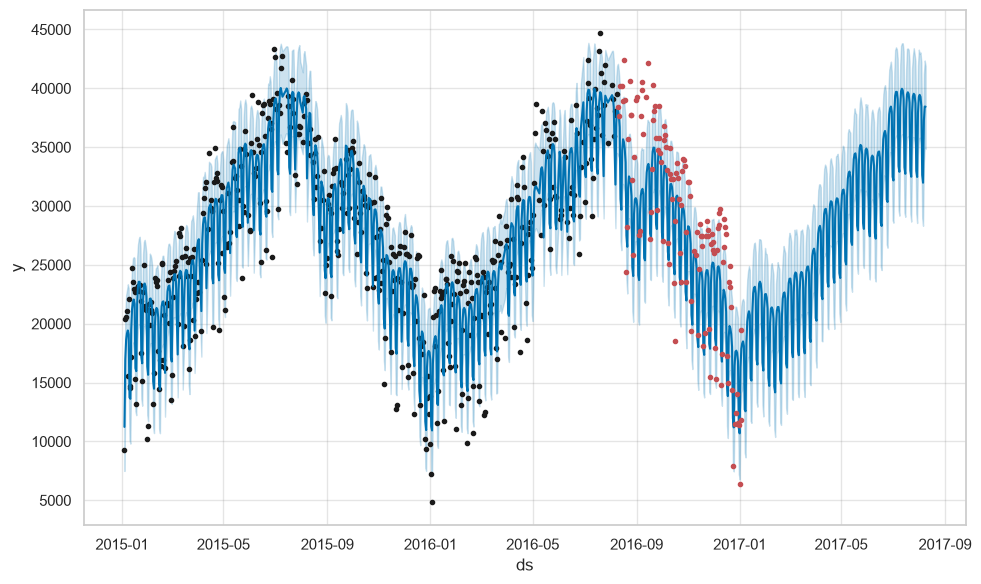

In [587]:
fig1 = modelo_sem_outliers.plot(previsao)
plt.plot(df_teste['ds'], df_teste['y'], '.r')

In [588]:
df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste, on='ds')
df_comparacao

,ds,yhat,y
0,2016-08-10,38158.494944,38430
1,2016-08-11,37743.682767,37626
2,2016-08-12,36700.561369,40159
3,2016-08-15,34731.625262,40236
4,2016-08-16,35674.247477,38911
...,...,...,...
121,2016-12-30,16811.841017,11566
122,2016-12-31,11106.066740,11424
123,2017-01-01,10688.052795,6421
124,2017-01-02,16296.326657,11823


In [589]:
mse = mean_squared_error(df_comparacao['y'], df_comparacao['yhat'])
rmse = np.sqrt(mse)

print(f'MSE: {mse}, RMSE: {rmse}')

MSE: 15478786.775128596, RMSE: 3934.3089323448653


In [590]:
np.random.seed(4587)

modelo_sem_outliers = Prophet(yearly_seasonality=True)
modelo_sem_outliers.fit(df_treino)
futuro = modelo_sem_outliers.make_future_dataframe(periods=150, freq='D')
previsao = modelo_sem_outliers.predict(futuro)

13:49:42 - cmdstanpy - INFO - Chain [1] start processing
13:49:42 - cmdstanpy - INFO - Chain [1] done processing


In [591]:
np.random.seed(4587)

modelo_sem_outliers = Prophet(yearly_seasonality=True)
modelo_sem_outliers.fit(df_treino)
futuro = modelo_sem_outliers.make_future_dataframe(periods=365, freq='D')
previsao = modelo_sem_outliers.predict(futuro)

13:49:42 - cmdstanpy - INFO - Chain [1] start processing
13:49:43 - cmdstanpy - INFO - Chain [1] done processing


In [592]:
from prophet.plot import plot_plotly

In [593]:
import plotly.graph_objects as go
import prophet.plot
from prophet.plot import plot_plotly

# Força o Prophet a enxergar o módulo 'go' que ele esqueceu de importar internamente
prophet.plot.go = go

# Renderiza o gráfico interativo sem erros
fig = plot_plotly(modelo_sem_outliers, previsao)
fig.show()



# 📈 Otimização de Séries Temporais: Sazonalidade, Outliers e Visualização Interativa

Concluímos a etapa de refinamento do modelo preditivo, focando no isolamento de ruídos e na calibração de hiperparâmetros para elevar a precisão das projeções:

* **Customização de Componentes Sazonais:** Ajustamos a arquitetura do modelo adicionando componentes de sazonalidade específicos à dinâmica da série temporal, permitindo capturar oscilações periódicas complexas que fogem do padrão linear.
* **Saneamento de Discrepâncias (Outliers):** Implementamos rotinas de identificação e remoção de valores atípicos (*outliers*) no histórico. Avaliamos os diferentes impactos e abordagens teóricas de tratamento para evitar que anomalias pontuais enviesem as previsões de longo prazo.
* **Manipulação de Janelas de Inferência:** Customizamos o horizonte preditivo do algoritmo, alterando o intervalo e o período do grid de dados futuros gerado para simular diferentes cenários de projeção.
* **Interface Dinâmica de Diagnóstico (Plotly):** Construímos gráficos dinâmicos utilizando a integração com a biblioteca Plotly. Solucionamos o erro de escopo interno (*namespace*) injetando explicitamente a dependência de `graph_objects` no backend do Prophet, viabilizando a inspeção interativa de tendências e bandas de incerteza.


In [595]:
import sys

print("="*65)
print("🔍 MONITOR DE HOMOLOGAÇÃO: SAZONALIDADE, OUTLIERS E PLOTLY")
print("="*65)

erros_fatais = 0
avisos_sistema = 0

# 1. Verificação do Tratamento de Outliers
if 'modelo_sem_outliers' in locals() or 'modelo_sem_outliers' in globals():
    print("✅ [OK] Objeto do Modelo: 'modelo_sem_outliers' inicializado com sucesso.")
else:
    print("❌ [ERRO] Objeto do Modelo: 'modelo_sem_outliers' não foi localizado na memória.")
    erros_fatais += 1

# 2. Verificação do Patch de Correção do Plotly (NameError)
if 'prophet.plot' in sys.modules or 'prophet' in sys.modules:
    import prophet.plot
    if hasattr(prophet.plot, 'go'):
        print("✅ [OK] Injeção Gráfica: Patch do Plotly aplicado. Erro 'name go is not defined' sanado.")
    else:
        print("⚠️ [AVISO] Injeção Gráfica: O patch 'prophet.plot.go = go' não foi detectado na sessão.")
        avisos_sistema += 1
else:
    print("❌ [ERRO] Bibliotecas: O pacote Prophet não está carregado nesta sessão.")
    erros_fatais += 1

# 3. Verificação do Horizonte de Previsão
if 'previsao' in locals() or 'previsao' in globals():
    colunas_obrigatorias = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
    if all(col in previsao.columns for col in colunas_obrigatorias):
        print(f"✅ [OK] Horizonte Temporal: Estrutura de predição íntegra ({len(previsao)} linhas geradas).")
    else:
        print("❌ [ERRO] Horizonte Temporal: A tabela 'previsao' não possui os eixos canônicos do Prophet.")
        erros_fatais += 1
else:
    print("❌ [ERRO] Horizonte Temporal: Matriz 'previsao' ausente na memória ativa.")
    erros_fatais += 1

# 4. Avaliação Comparativa de Desempenho (Opcional)
if 'rmse' in locals() or 'rmse' in globals():
    print(f"📊 [INFO] Mapeamento de Performance Corrente: RMSE Base = {rmse:.2f} bicicletas.")
    
print("="*65)
if erros_fatais == 0:
    if avisos_sistema == 0:
        print("🚀 PIPELINE 100% HOMOLOGADO E PRONTO PARA O COMPARTILHAMENTO!")
    else:
        print("💡 PIPELINE OPERACIONAL: Fluxo principal íntegro com avisos cosméticos.")
else:
    print(f"⚠️ SESSÃO INSTÁVEL: Encontrados {erros_fatais} pontos críticos que impedem a execução.")
print("="*65)


🔍 MONITOR DE HOMOLOGAÇÃO: SAZONALIDADE, OUTLIERS E PLOTLY
✅ [OK] Objeto do Modelo: 'modelo_sem_outliers' inicializado com sucesso.
✅ [OK] Injeção Gráfica: Patch do Plotly aplicado. Erro 'name go is not defined' sanado.
✅ [OK] Horizonte Temporal: Estrutura de predição íntegra (870 linhas geradas).
📊 [INFO] Mapeamento de Performance Corrente: RMSE Base = 3934.31 bicicletas.
🚀 PIPELINE 100% HOMOLOGADO E PRONTO PARA O COMPARTILHAMENTO!
